In [27]:
# pip install nbconvert
import subprocess
import sys

# Esegui setup_raw_data.py
result_setup = subprocess.run([sys.executable, '../script/setup_raw_data.py'], 
                              capture_output=True, text=True)
print(result_setup.stdout)
if result_setup.stderr:
    print("STDERR:", result_setup.stderr)

# Esegui notebook pulizia con nbconvert
result_clean = subprocess.run([
    sys.executable, '-m', 'nbconvert', 
    '--to', 'notebook', 
    '--execute', 
    '--ExecutePreprocessor.timeout=600',
    '../notebook/pulizia.ipynb'
], capture_output=True, text=True, cwd='.')

print(result_clean.stdout)
if result_clean.stderr:
    print("STDERR:", result_clean.stderr)


Creazione tabella raw_data...
Tabella raw_data creata

Credenziali caricate!
Credenziali caricate da: c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\script\..\local\analisi-ansia-dcecdb75c868.json

Connessione a Google Sheets...
Trovate 169 risposte
Numero colonne: 39

Inizio importazione dati in raw_data...

Salvate 10 righe...
Salvate 20 righe...
Salvate 30 righe...
Salvate 40 righe...
Salvate 50 righe...
Salvate 60 righe...
Salvate 70 righe...
Salvate 80 righe...
Salvate 90 righe...
Salvate 100 righe...
Salvate 110 righe...
Salvate 120 righe...
Salvate 130 righe...
Salvate 140 righe...
Salvate 150 righe...
Salvate 160 righe...

Importazione completata!
   - Righe inserite: 169
   - Righe saltate: 0

Fine

STDERR: c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.10) which Google will stop supporting in ne

# Connessione al Database
Caricamento dei dati dalla tabella `clean_data` per l'analisi di clustering della personalità basata su dimensioni di ansia, strategie di coping e resilienza.

In [28]:
import pandas as pd
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

conn = get_mysql_connection()

# Carica tutti i dati da clean_data in un DataFrame
query = "SELECT * FROM clean_data"
df = pd.read_sql(query, conn)

conn.close()

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
df.head()

Dataset caricato: 550 righe, 37 colonne


C:\Users\Utente\AppData\Local\Temp\ipykernel_13440\3834313147.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,email,contesto,età,genere,area_geo,anni_esperienza,Item_1,Item_2,Item_3,...,Item_21,Item_22,Item_23,Item_24,Item_25,Item_26,Item_27,Item_28,Item_29,Item_30
0,1,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,...,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...
1,2,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,...,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...
2,3,None,Entrambi,24,Femmina,Nord Italia,5.0,4,5,4,...,5,5,1,1,2,2,4,5,5,Durante gli esami e se devo interagire con gli...
3,4,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,...,4,1,3,3,5,2,2,2,4,Durante gli esami
4,5,None,Studio,26,Femmina,Nord Italia,7.0,4,5,3,...,4,1,3,3,5,2,2,2,4,Durante gli esami


# 1. Feature Engineering per Dimensioni di Ansia

Creazione di feature composite calcolando le medie su specifici item del questionario:
- **ansia_prestazione**: Performance anxiety (Item 1, 2, 3, 4, 6, 11, 20, 21)
- **ansia_accademica**: Academic anxiety (Item 7, 8, 9, 10)
- **ansia_lavorativa**: Work anxiety (Item 12, 13, 14, 15)
- **ansia_totale**: Media delle tre dimensioni
- **coping**: Strategie di gestione dello stress (Item 23, 24, 25, 26)
- **resilienza**: Capacità di recupero (coping - ansia_totale)
- **evitamento**: Strategie evitanti (Item 10, 15, 27, 28)
- **gap**: Gap percettivo (Item 8 - coping)

In [29]:
import numpy as np

# Feature Engineering: Creazione delle dimensioni di ansia
df["ansia_prestazione"] = df[["Item_1", "Item_2", "Item_3", "Item_4", "Item_6", "Item_11", "Item_20", "Item_21"]].mean(axis=1)
df["ansia_accademica"] = df[["Item_7", "Item_8", "Item_9", "Item_10"]].mean(axis=1)
df["ansia_lavorativa"] = df[["Item_12", "Item_13", "Item_14", "Item_15"]].mean(axis=1)
df['ansia_totale'] = df[["ansia_prestazione", "ansia_accademica", "ansia_lavorativa"]].mean(axis=1)

# Strategie di coping e resilienza
df["coping"] = df[["Item_23", "Item_24", "Item_25", "Item_26"]].mean(axis=1)
df["resilienza"] = (df["coping"] - df["ansia_totale"])
df["evitamento"] = df[["Item_10", "Item_15", "Item_27", "Item_28"]].mean(axis=1)
df["gap"] = df["Item_8"] - df["coping"]

# Selezione delle feature per clustering
features = [
    "ansia_totale",
    "coping",
    "evitamento",
    "resilienza",
    "gap"
]

# Preparazione della matrice X (rimozione dei valori mancanti)
X = df[features].dropna()

print(f"Feature engineering completato!")
print(f"Numero di record con valori completi: {X.shape[0]}")
print(f"\nStatistiche descrittive delle feature:")
print(X.describe())

Feature engineering completato!
Numero di record con valori completi: 538

Statistiche descrittive delle feature:
       ansia_totale      coping  evitamento  resilienza         gap
count    538.000000  538.000000  538.000000  538.000000  538.000000
mean       2.930131    3.016264    2.444238    0.086133   -0.445632
std        0.858634    0.797074    1.091125    1.431660    1.566331
min        1.214286    1.000000    1.000000   -3.750000   -3.500000
25%        2.278274    2.500000    1.500000   -0.864583   -1.500000
50%        2.910714    3.000000    2.250000    0.270833   -0.500000
75%        3.589286    3.750000    3.250000    1.125000    0.500000
max        4.869048    4.750000    5.000000    2.845238    3.750000


# 2. Standardizzazione dei Dati

Applicazione di StandardScaler per normalizzare la matrice delle feature X, assicurando che tutte le feature siano sulla stessa scala prima dell'applicazione degli algoritmi di clustering.

In [30]:
from sklearn.preprocessing import StandardScaler

# Standardizzazione delle feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dati standardizzati: media ≈ 0, std ≈ 1")
print(f"Media delle feature standardizzate: {X_scaled.mean(axis=0).round(4)}")
print(f"Dev. Std. delle feature standardizzate: {X_scaled.std(axis=0).round(4)}")

Dati standardizzati: media ≈ 0, std ≈ 1
Media delle feature standardizzate: [-0.  0. -0.  0. -0.]
Dev. Std. delle feature standardizzate: [1. 1. 1. 1. 1.]


# 3. K-Means Clustering con Selezione del K Ottimale

Implementazione dell'algoritmo K-Means e assegnazione delle etichette di cluster al dataframe. Creazione di una funzione per denominare i cluster basandosi su soglie delle feature.

In [31]:
from sklearn.cluster import KMeans

# K-Means iniziale con k=4 (da verificare)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Assegnazione dei cluster al dataframe originale
df.loc[X.index, "cluster"] = clusters

print(f"K-Means clustering eseguito con k=4")
print(f"Distribuzione iniziale dei cluster:")
print(df["cluster"].value_counts().sort_index())

K-Means clustering eseguito con k=4
Distribuzione iniziale dei cluster:
cluster
0.0    188
1.0    138
2.0     73
3.0    139
Name: count, dtype: int64


# 4. Denominazione dei Cluster e Interpretazione

Definizione della funzione `assegna_nome_cluster()` utilizzando logica condizionale su ansia, coping, evitamento e gap. Mappatura dei centroidi dei cluster a profili psicologici significativi.

In [32]:
def assegna_nome_cluster(row):
    """
    Assegna un nome semantico al cluster basato su soglie delle feature.
    
    Profili psicologici:
    - Ansiosi Disfunzionali: Alta ansia, basso coping, gap percettivo significativo
    - Ansiosi Funzionali: Alta ansia ma coping efficace, gap ridotto
    - Resilienti: Bassa ansia, coping elevato, resilienza marcata
    - Evitanti: Elevato evitamento, coping ridotto
    - Intermedio: Profilo misto, caratteristiche non estreme
    """
    ansia = row["ansia_totale"]
    coping = row["coping"]
    evitamento = row["evitamento"]
    gap = row["gap"]
    autoeff = row["resilienza"]
    
    if ansia > 0.6 and coping < 0.4 and gap > 0.2:
        return "Ansiosi Disfunzionali"
    
    elif ansia > 0.6 and coping >= 0.5 and gap <= 0.2:
        return "Ansiosi Funzionali"
    
    elif ansia < 0.4 and coping >= 0.6 and autoeff >= 0.6:
        return "Resilienti"
    
    elif evitamento > 0.6 and coping < 0.5:
        return "Evitanti"
    
    else:
        return "Intermedio"


# Calcolo dei centroidi nei dati originali
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)
centroids_df["cluster"] = range(4)

# Assegnazione dei nomi ai cluster basata sui centroidi
centroids_df["nome_cluster"] = centroids_df.apply(assegna_nome_cluster, axis=1)

print("Centroidi dei cluster con nomi assegnati:")
print(centroids_df)

Centroidi dei cluster con nomi assegnati:
   ansia_totale    coping  evitamento  resilienza       gap  cluster  \
0      2.848721  3.304521    2.264628    0.455800 -0.740691        0   
1      3.253278  2.436594    2.804348   -0.816684  0.244565        1   
2      4.341080  1.969178    4.138128   -2.371902  2.085616        2   
3      1.978417  3.751799    1.440048    1.773381 -2.061151        3   

         nome_cluster  
0  Ansiosi Funzionali  
1          Intermedio  
2          Intermedio  
3  Ansiosi Funzionali  


In [33]:
# Mappatura dei nomi ai cluster e aggiunta al dataframe
cluster_map = centroids_df.set_index("cluster")["nome_cluster"].to_dict()
df["cluster_nome"] = df["cluster"].map(cluster_map)

print("\nPrimi record con cluster e nomi:")
print(df[["cluster", "cluster_nome"]].head(10))

print("\nDistribuzione dei cluster denominati:")
print(df["cluster_nome"].value_counts())

print("\nMedie delle feature per cluster:")
print(df.groupby("cluster_nome")[features].mean().round(3))


Primi record con cluster e nomi:
   cluster        cluster_nome
0      2.0          Intermedio
1      2.0          Intermedio
2      2.0          Intermedio
3      0.0  Ansiosi Funzionali
4      0.0  Ansiosi Funzionali
5      0.0  Ansiosi Funzionali
6      0.0  Ansiosi Funzionali
7      1.0          Intermedio
8      1.0          Intermedio
9      0.0  Ansiosi Funzionali

Distribuzione dei cluster denominati:
cluster_nome
Ansiosi Funzionali    327
Intermedio            211
Name: count, dtype: int64

Medie delle feature per cluster:


                    ansia_totale  coping  evitamento  resilienza    gap
cluster_nome                                                           
Ansiosi Funzionali         2.479   3.495       1.914       1.016 -1.302
Intermedio                 3.630   2.275       3.266      -1.355  0.882


# 5. Elbow Method e Analisi dell'Inerzia

Calcolo dell'inerzia per K da 1 a 10 utilizzando K-Means. Grafico inerzia vs K e implementazione della funzione `trova_elbow()` per trovare il numero ottimale di cluster utilizzando la massima distanza dalla linea che connette gli endpoints.

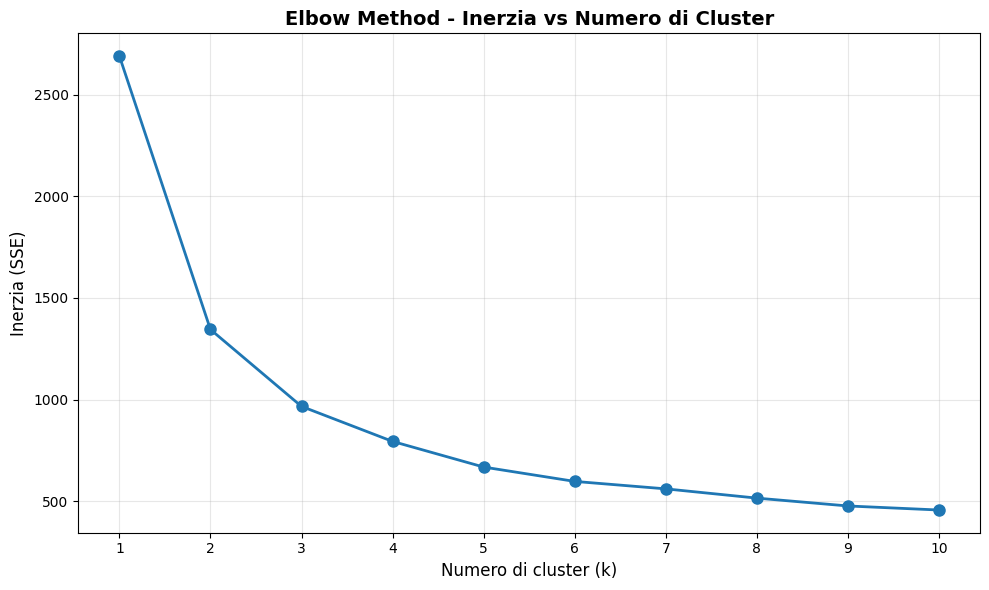

Valori di inerzia per ogni k:
k=1: inerzia=2690.00
k=2: inerzia=1344.69
k=3: inerzia=966.28
k=4: inerzia=794.00
k=5: inerzia=667.93
k=6: inerzia=597.30
k=7: inerzia=560.64
k=8: inerzia=515.13
k=9: inerzia=476.52
k=10: inerzia=456.55


In [34]:
import matplotlib.pyplot as plt

# Calcolo dell'inerzia per diversi valori di K
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot dell'Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linewidth=2, markersize=8)
plt.xlabel("Numero di cluster (k)", fontsize=12)
plt.ylabel("Inerzia (SSE)", fontsize=12)
plt.title("Elbow Method - Inerzia vs Numero di Cluster", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print("Valori di inerzia per ogni k:")
for k, inert in zip(K_range, inertia):
    print(f"k={k}: inerzia={inert:.2f}")

In [35]:
def trova_elbow(K, inertia):
    """
    Trova il punto dell'elbow utilizzando il metodo della massima distanza.
    
    Calcola la distanza perpendicolare di ogni punto dalla linea
    che connette il primo e l'ultimo punto.
    """
    # Punti iniziale e finale
    p1 = np.array([K[0], inertia[0]])
    p2 = np.array([K[-1], inertia[-1]])
    
    distanze = []
    
    for i in range(len(K)):
        p = np.array([K[i], inertia[i]])
        
        # Distanza punto-linea (cross product / norma)
        dist = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distanze.append(dist)
    
    # Ritorna il k corrispondente alla massima distanza
    return K[np.argmax(distanze)]


# Ricerca dell'elbow
k_elbow = trova_elbow(list(K_range), inertia)
print(f"\nNumero ottimale di cluster (Elbow Method): {k_elbow}")


Numero ottimale di cluster (Elbow Method): 3


C:\Users\Utente\AppData\Local\Temp\ipykernel_13440\2987284414.py:18: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)


# 6. Valutazione Silhouette Score

Calcolo del silhouette_score per valori di K da 2 a 10. Creazione di un dataframe dei risultati tracciando k, inerzia e silhouette_score. Plot e identificazione del miglior k in base al massimo silhouette score.

In [36]:
from sklearn.metrics import silhouette_score

# Calcolo dello Silhouette Score per diversi k
results = []
K_range = range(2, 11)  # Silhouette non è definito per k=1

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, labels)
    
    results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": sil_score
    })

# Creazione del dataframe dei risultati
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by="silhouette_score", ascending=False)

print("Risultati di clustering per diversi k:")
print(results_df.to_string(index=False))

print("\nMigliori k per Silhouette Score:")
print(results_df_sorted.head(3))

Risultati di clustering per diversi k:
 k     inertia  silhouette_score
 2 1344.691142          0.411005
 3  966.283564          0.319498
 4  794.003383          0.285571
 5  667.931719          0.305259
 6  597.300035          0.276129
 7  560.641260          0.258168
 8  515.133712          0.267516
 9  476.515421          0.272040
10  456.554175          0.282043

Migliori k per Silhouette Score:
   k      inertia  silhouette_score
0  2  1344.691142          0.411005
1  3   966.283564          0.319498
3  5   667.931719          0.305259


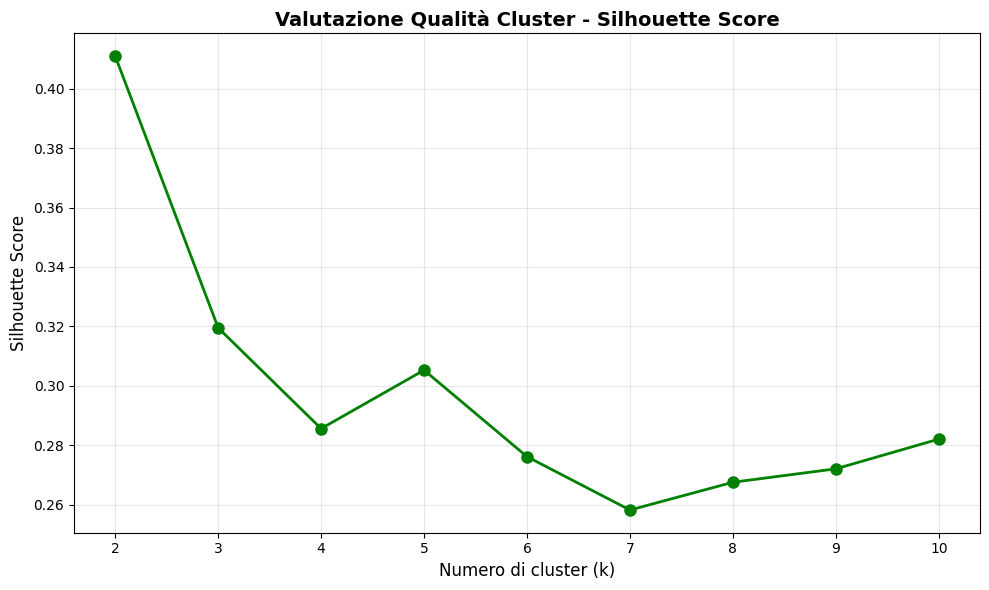


Miglior numero di cluster (Silhouette): k=2 con score=0.4110


In [37]:
# Plot dello Silhouette Score
plt.figure(figsize=(10, 6))
plt.plot(results_df["k"], results_df["silhouette_score"], marker='o', linewidth=2, markersize=8, color='green')
plt.xlabel("Numero di cluster (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Valutazione Qualità Cluster - Silhouette Score", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

# Identificazione del miglior k
best_k_silhouette = int(results_df.loc[results_df["silhouette_score"].idxmax(), "k"])
best_sil_score = results_df["silhouette_score"].max()
print(f"\nMiglior numero di cluster (Silhouette): k={best_k_silhouette} con score={best_sil_score:.4f}")

# 7. Validazione con Calinski-Harabasz Score

Calcolo del calinski_harabasz_score per ogni valore di k da 2 a 10. Plot dei CH scores e identificazione del miglior k. Confronto dei risultati con lo silhouette score per validare la qualità dei cluster.

In [38]:
from sklearn.metrics import calinski_harabasz_score

# Calcolo del Calinski-Harabasz Score per diversi k
ch_results = []
K_range_ch = range(2, 11)

for k in K_range_ch:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    ch_score = calinski_harabasz_score(X_scaled, labels)
    ch_results.append({
        "k": k,
        "ch_score": ch_score
    })

ch_df = pd.DataFrame(ch_results)

print("Calinski-Harabasz Score per diversi k:")
print(ch_df.to_string(index=False))

# Miglior k secondo CH
best_k_ch = int(ch_df.loc[ch_df["ch_score"].idxmax(), "k"])
best_ch_score = ch_df["ch_score"].max()
print(f"\nMiglior numero di cluster (CH Score): k={best_k_ch} con score={best_ch_score:.2f}")

Calinski-Harabasz Score per diversi k:
 k   ch_score
 2 536.246224
 3 477.183059
 4 425.045290
 5 403.395423
 6 372.782962
 7 336.129824
 8 319.661563
 9 307.160401
10 286.995123

Miglior numero di cluster (CH Score): k=2 con score=536.25


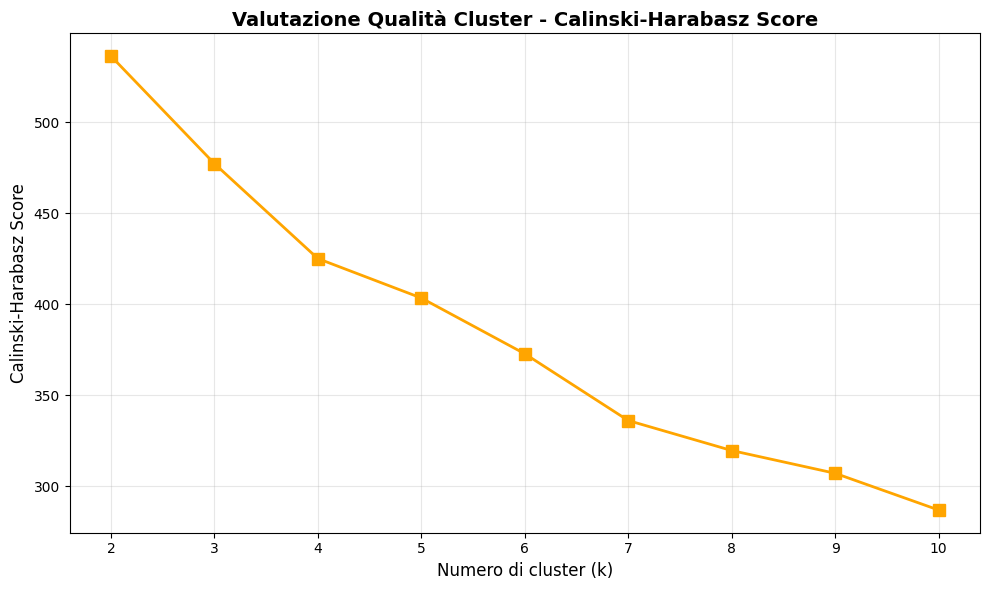


CONFRONTO TRA I METODI DI SELEZIONE DEL K:
Elbow Method suggerisce: k=3
Silhouette Score suggerisce: k=2
Calinski-Harabasz Score suggerisce: k=2


In [39]:
# Plot del Calinski-Harabasz Score
plt.figure(figsize=(10, 6))
plt.plot(ch_df["k"], ch_df["ch_score"], marker='s', linewidth=2, markersize=8, color='orange')
plt.xlabel("Numero di cluster (k)", fontsize=12)
plt.ylabel("Calinski-Harabasz Score", fontsize=12)
plt.title("Valutazione Qualità Cluster - Calinski-Harabasz Score", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range_ch)
plt.tight_layout()
plt.show()

# Confronto tra i metodi
print("\n" + "="*60)
print("CONFRONTO TRA I METODI DI SELEZIONE DEL K:")
print("="*60)
print(f"Elbow Method suggerisce: k={k_elbow}")
print(f"Silhouette Score suggerisce: k={best_k_silhouette}")
print(f"Calinski-Harabasz Score suggerisce: k={best_k_ch}")
print("="*60)

# 8. Riduzione della Dimensionalità con PCA e Visualizzazione

Applicazione di PCA con 2 componenti a X_scaled. Visualizzazione dei rapporti di varianza spiegata. Esecuzione del K-Means clustering sui dati trasformati con PCA e creazione di scatter plot con colorazione dei cluster nello spazio bidimensionale delle componenti principali.

In [40]:
from sklearn.decomposition import PCA

# Determinazione del k ottimale (usando Silhouette Score come principale)
best_k = best_k_silhouette
print(f"Utilizzo di k={best_k} per l'analisi successiva (basato su Silhouette Score)")

# Riduzione dimensionalità con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\nAnalisi PCA:")
print(f"Varianza spiegata dalla PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Varianza spiegata dalla PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Varianza totale spiegata (2 componenti): {sum(pca.explained_variance_ratio_):.4f}")

print(f"\nComponenti principali:")
print(f"PC1 pesi: {dict(zip(features, pca.components_[0].round(3)))}")
print(f"PC2 pesi: {dict(zip(features, pca.components_[1].round(3)))}")

Utilizzo di k=2 per l'analisi successiva (basato su Silhouette Score)

Analisi PCA:
Varianza spiegata dalla PC1: 0.7676
Varianza spiegata dalla PC2: 0.1254
Varianza totale spiegata (2 componenti): 0.8930

Componenti principali:
PC1 pesi: {'ansia_totale': np.float64(-0.455), 'coping': np.float64(0.409), 'evitamento': np.float64(-0.422), 'resilienza': np.float64(0.501), 'gap': np.float64(-0.444)}
PC2 pesi: {'ansia_totale': np.float64(0.439), 'coping': np.float64(0.697), 'evitamento': np.float64(0.527), 'resilienza': np.float64(0.124), 'gap': np.float64(-0.17)}


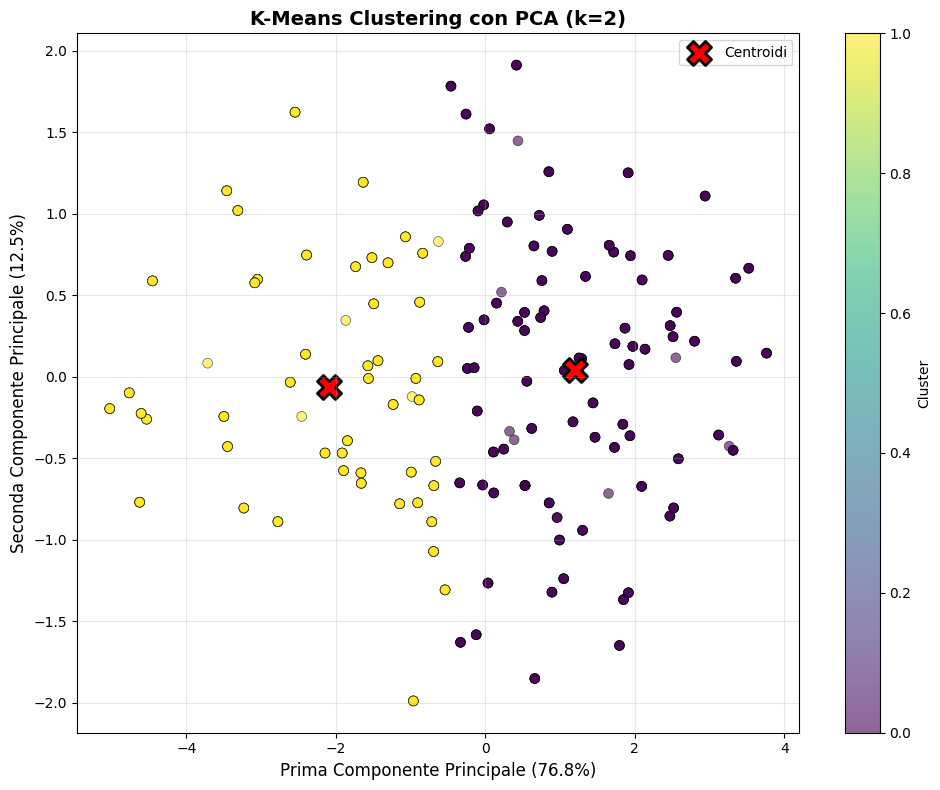

Distribuzione dei cluster nella riduzione PCA:
Cluster 0: 342 punti (63.6%)
Cluster 1: 196 punti (36.4%)


In [41]:
# K-Means clustering su componenti PCA
kmeans_pca = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# Centroidi PCA
centroids_pca = kmeans_pca.cluster_centers_

# Visualizzazione
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca, cmap='viridis', 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Plotta i centroidi
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', 
           s=300, edgecolors='black', linewidth=2, label='Centroidi')

plt.xlabel(f'Prima Componente Principale ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'Seconda Componente Principale ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.title(f'K-Means Clustering con PCA (k={best_k})', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Distribuzione dei cluster nella riduzione PCA:")
unique, counts = np.unique(clusters_pca, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} punti ({c/len(clusters_pca)*100:.1f}%)")

# 9. Metodi Alternativi di Clustering (DBSCAN e GMM)

Implementazione di DBSCAN con eps=0.5 e min_samples=5 per identificare cluster e punti di rumore. Implementazione di Gaussian Mixture Model con n_components=best_k. Visualizzazione di entrambi i metodi nello spazio PCA e confronto con K-Means.

DBSCAN Clustering
--------------------------------------------------
Numero di cluster trovati: 22
Numero di punti rumore: 314
Percentuale di rumore: 58.36%


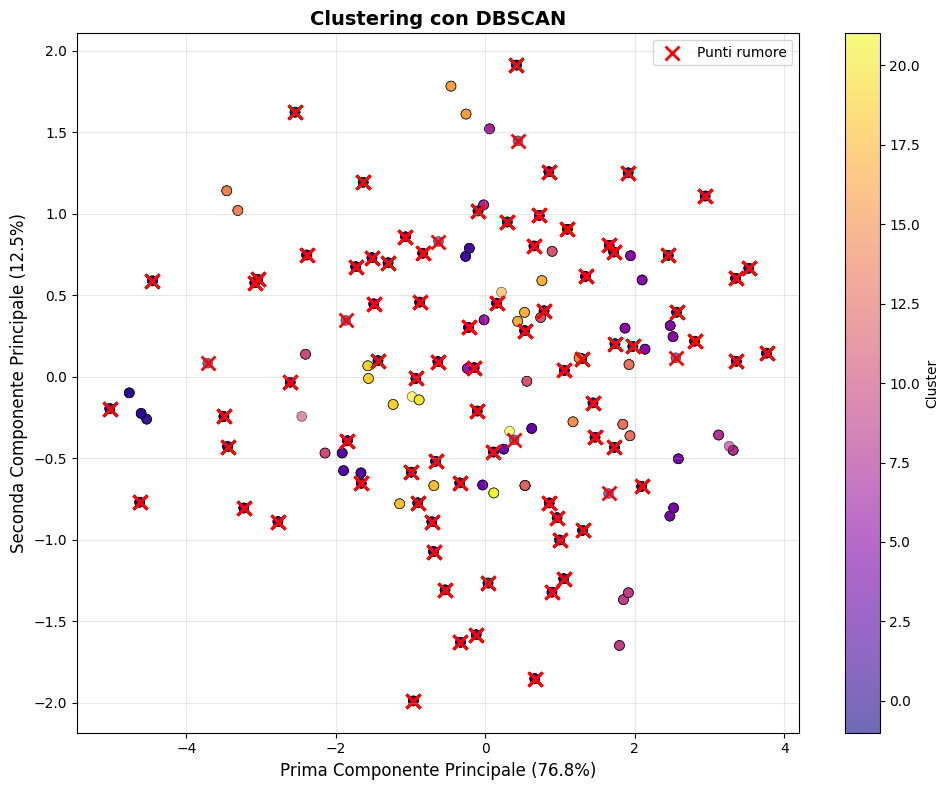

In [42]:
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# DBSCAN - algoritmo basato sulla densità
print("DBSCAN Clustering")
print("-" * 50)

dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise = list(clusters_dbscan).count(-1)

print(f"Numero di cluster trovati: {n_clusters_dbscan}")
print(f"Numero di punti rumore: {n_noise}")
print(f"Percentuale di rumore: {n_noise/len(clusters_dbscan)*100:.2f}%")

# Visualizzazione DBSCAN
plt.figure(figsize=(10, 8))
scatter_dbscan = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_dbscan, cmap='plasma', 
                            alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Evidenzia i punti di rumore
noise_mask = clusters_dbscan == -1
if n_noise > 0:
    plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], c='red', marker='x', 
               s=100, linewidth=2, label='Punti rumore')

plt.xlabel(f'Prima Componente Principale ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'Seconda Componente Principale ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.title('Clustering con DBSCAN', fontsize=14, fontweight='bold')
plt.colorbar(scatter_dbscan, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Gaussian Mixture Model
--------------------------------------------------
AIC: -1418.22
BIC: -1242.42
Log-likelihood: 1.3943


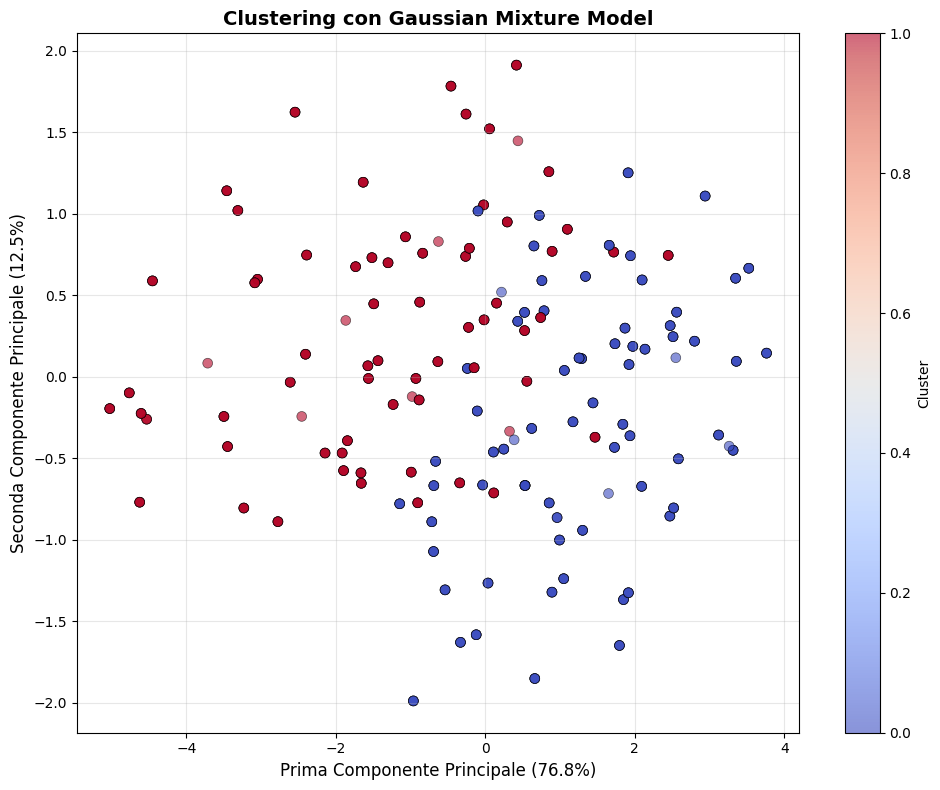


Distribuzione dei cluster GMM:
Cluster 0: 276 punti (51.3%)
Cluster 1: 262 punti (48.7%)


In [43]:
# Gaussian Mixture Model
print("\nGaussian Mixture Model")
print("-" * 50)

gmm = GaussianMixture(n_components=best_k, random_state=42)
clusters_gmm = gmm.fit_predict(X_scaled)

aic = gmm.aic(X_scaled)
bic = gmm.bic(X_scaled)

print(f"AIC: {aic:.2f}")
print(f"BIC: {bic:.2f}")
print(f"Log-likelihood: {gmm.score(X_scaled):.4f}")

# Visualizzazione GMM
plt.figure(figsize=(10, 8))
scatter_gmm = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_gmm, cmap='coolwarm', 
                         alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

plt.xlabel(f'Prima Componente Principale ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'Seconda Componente Principale ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.title('Clustering con Gaussian Mixture Model', fontsize=14, fontweight='bold')
plt.colorbar(scatter_gmm, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nDistribuzione dei cluster GMM:")
unique_gmm, counts_gmm = np.unique(clusters_gmm, return_counts=True)
for u, c in zip(unique_gmm, counts_gmm):
    print(f"Cluster {u}: {c} punti ({c/len(clusters_gmm)*100:.1f}%)")

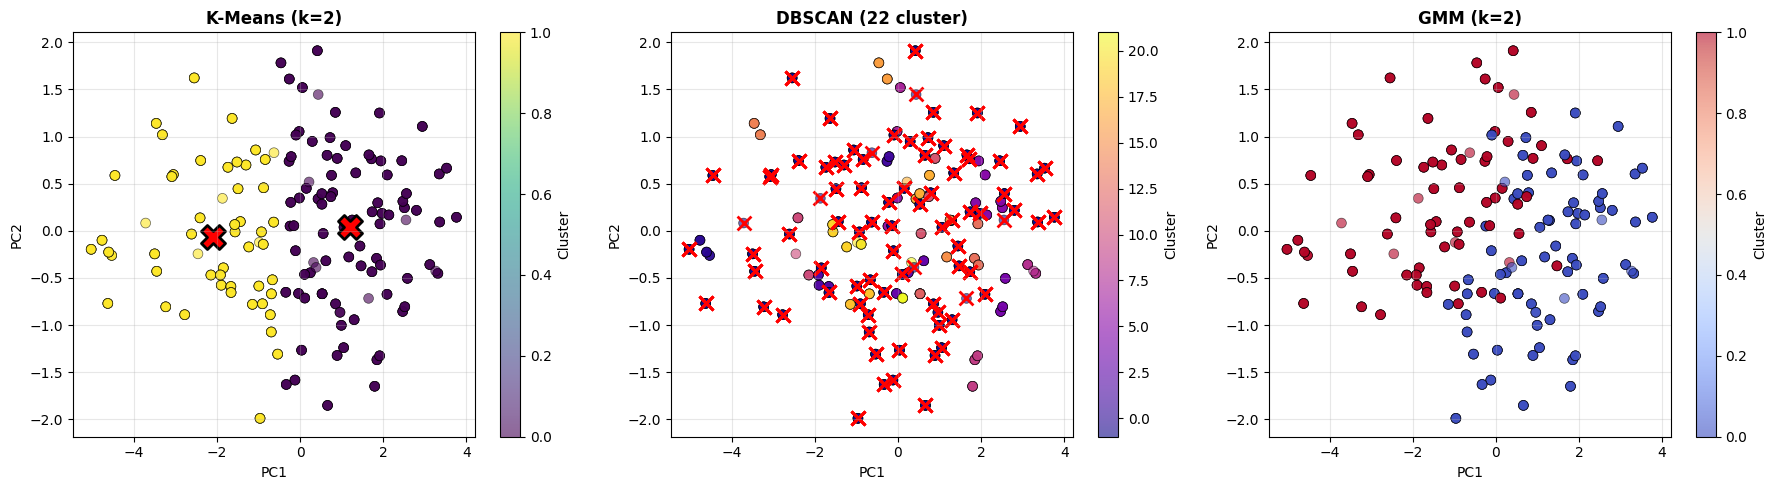

Confronto visivo dei tre metodi di clustering completato.


In [44]:
# Confronto visivo dei tre metodi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca, cmap='viridis', 
                          alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', 
               s=300, edgecolors='black', linewidth=2)
axes[0].set_title(f'K-Means (k={best_k})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# DBSCAN
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_dbscan, cmap='plasma', 
                          alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
if n_noise > 0:
    axes[1].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], c='red', marker='x', 
                   s=100, linewidth=2, label='Rumore')
axes[1].set_title(f'DBSCAN ({n_clusters_dbscan} cluster)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

# GMM
scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_gmm, cmap='coolwarm', 
                          alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[2].set_title(f'GMM (k={best_k})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[2], label='Cluster')

plt.tight_layout()
plt.show()

print("Confronto visivo dei tre metodi di clustering completato.")

# 10. Stabilità dei Cluster e Analisi dell'Importanza delle Feature

Esecuzione dell'analisi di stabilità del bootstrapping (n_boot=100) utilizzando dati ricampionati per calcolare gli silhouette scores. Addestramento di RandomForestClassifier sui feature scalate con le etichette di cluster come target per calcolare e classificare feature_importances per la discriminazione dei cluster.

ANALISI DI STABILITÀ E IMPORTANZA DELLE FEATURE

1. ANALISI DI STABILITÀ CON BOOTSTRAPPING
----------------------------------------------------------------------
Numero di bootstrap eseguiti: 100
Silhouette Score medio: 0.4117
Silhouette Score std dev: 0.0141
Silhouette Score min: 0.3799
Silhouette Score max: 0.4461


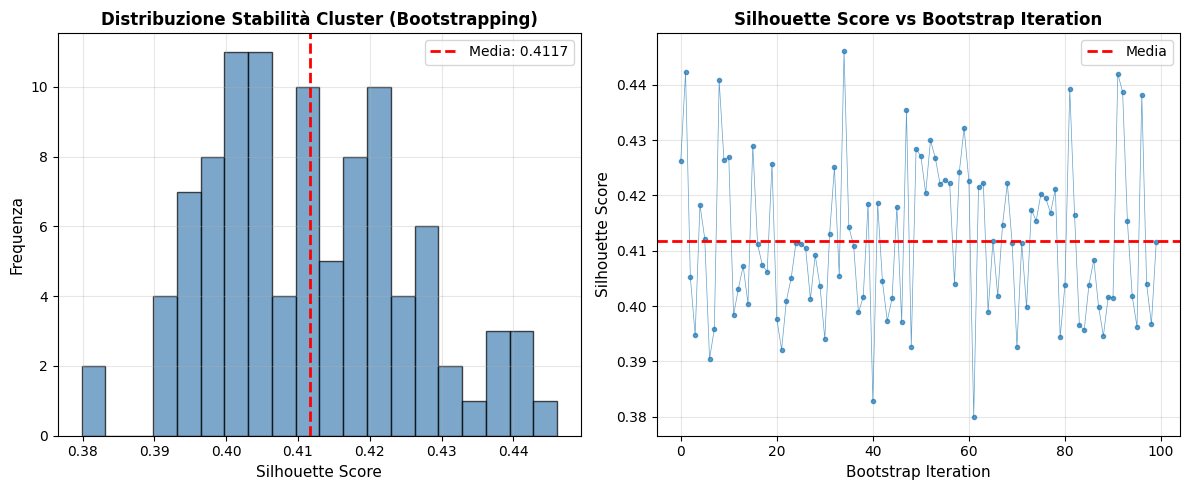

In [45]:
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

print("ANALISI DI STABILITÀ E IMPORTANZA DELLE FEATURE")
print("=" * 70)

# Ricalcola i cluster con best_k per coerenza
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters_final = kmeans_final.fit_predict(X_scaled)

# Stabilità dei cluster tramite bootstrapping
print("\n1. ANALISI DI STABILITÀ CON BOOTSTRAPPING")
print("-" * 70)

n_boot = 100
stability_scores = []
bootstrap_results = []

for i in range(n_boot):
    # Bootstrap sample
    indices = resample(range(len(X_scaled)), n_samples=len(X_scaled), random_state=i)
    X_boot = X_scaled[indices]
    
    # Clustering sul campione bootstrap
    kmeans_boot = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    clusters_boot = kmeans_boot.fit_predict(X_boot)
    
    # Calcolo dello silhouette score
    if len(np.unique(clusters_boot)) > 1:
        sil_boot = silhouette_score(X_boot, clusters_boot)
        stability_scores.append(sil_boot)
        bootstrap_results.append({
            'bootstrap': i,
            'silhouette': sil_boot
        })

bootstrap_df = pd.DataFrame(bootstrap_results)

print(f"Numero di bootstrap eseguiti: {n_boot}")
print(f"Silhouette Score medio: {np.mean(stability_scores):.4f}")
print(f"Silhouette Score std dev: {np.std(stability_scores):.4f}")
print(f"Silhouette Score min: {np.min(stability_scores):.4f}")
print(f"Silhouette Score max: {np.max(stability_scores):.4f}")

# Plot della stabilità
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(stability_scores, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(stability_scores), color='red', linestyle='--', linewidth=2, label=f'Media: {np.mean(stability_scores):.4f}')
plt.xlabel('Silhouette Score', fontsize=11)
plt.ylabel('Frequenza', fontsize=11)
plt.title('Distribuzione Stabilità Cluster (Bootstrapping)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(n_boot), stability_scores, marker='o', linestyle='-', linewidth=0.5, markersize=3, alpha=0.7)
plt.axhline(np.mean(stability_scores), color='red', linestyle='--', linewidth=2, label='Media')
plt.xlabel('Bootstrap Iteration', fontsize=11)
plt.ylabel('Silhouette Score', fontsize=11)
plt.title('Silhouette Score vs Bootstrap Iteration', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


2. IMPORTANZA DELLE FEATURE PER DISCRIMINAZIONE DEI CLUSTER
----------------------------------------------------------------------

Importanza delle feature per la distinzione dei cluster:
     feature  importance  importance_std
  resilienza    0.504690        0.353224
ansia_totale    0.167664        0.211518
         gap    0.161943        0.202243
      coping    0.111642        0.167412
  evitamento    0.054061        0.059136


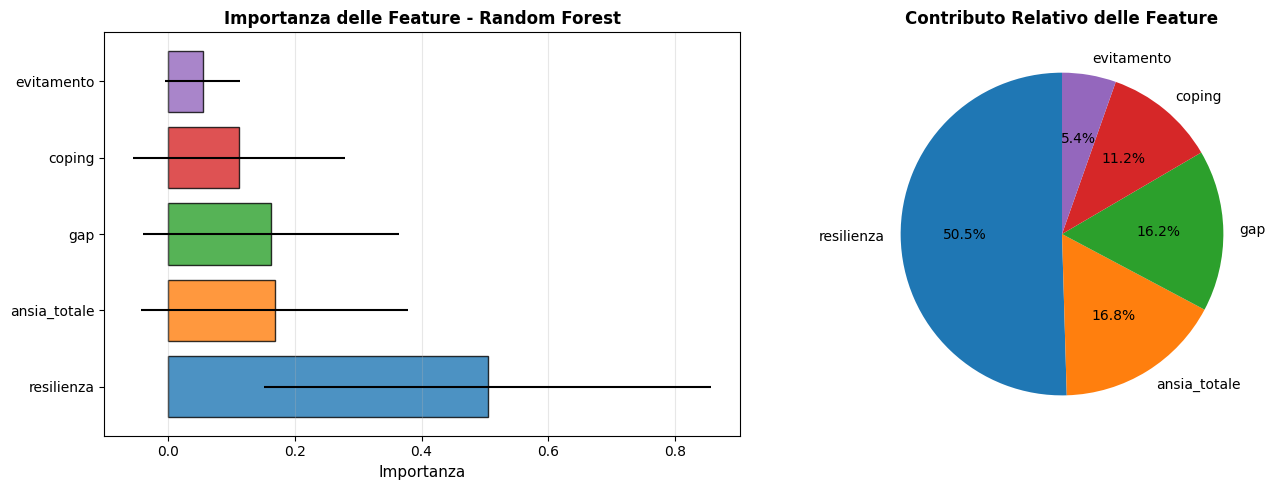


Feature più importante: resilienza (0.5047)
Feature meno importante: evitamento (0.0541)


In [46]:
# Importanza delle feature per discriminare i cluster
print("\n2. IMPORTANZA DELLE FEATURE PER DISCRIMINAZIONE DEI CLUSTER")
print("-" * 70)

# Addestramento Random Forest con cluster come target
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_scaled, clusters_final)

# Estrazione importanza delle feature
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_,
    'importance_std': np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
}).sort_values('importance', ascending=False)

print("\nImportanza delle feature per la distinzione dei cluster:")
print(feature_importance.to_string(index=False))

# Visualizzazione importanza
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
axes[0].barh(feature_importance['feature'], feature_importance['importance'], 
            xerr=feature_importance['importance_std'], color=colors, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Importanza', fontsize=11)
axes[0].set_title('Importanza delle Feature - Random Forest', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Pie chart
axes[1].pie(feature_importance['importance'], labels=feature_importance['feature'], 
           autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Contributo Relativo delle Feature', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nFeature più importante: {feature_importance.iloc[0]['feature']} ({feature_importance.iloc[0]['importance']:.4f})")
print(f"Feature meno importante: {feature_importance.iloc[-1]['feature']} ({feature_importance.iloc[-1]['importance']:.4f})")


Accuracy della classificazione Random Forest: 1.0000

Classification Report:
              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00       342
   Cluster 1       1.00      1.00      1.00       196

    accuracy                           1.00       538
   macro avg       1.00      1.00      1.00       538
weighted avg       1.00      1.00      1.00       538



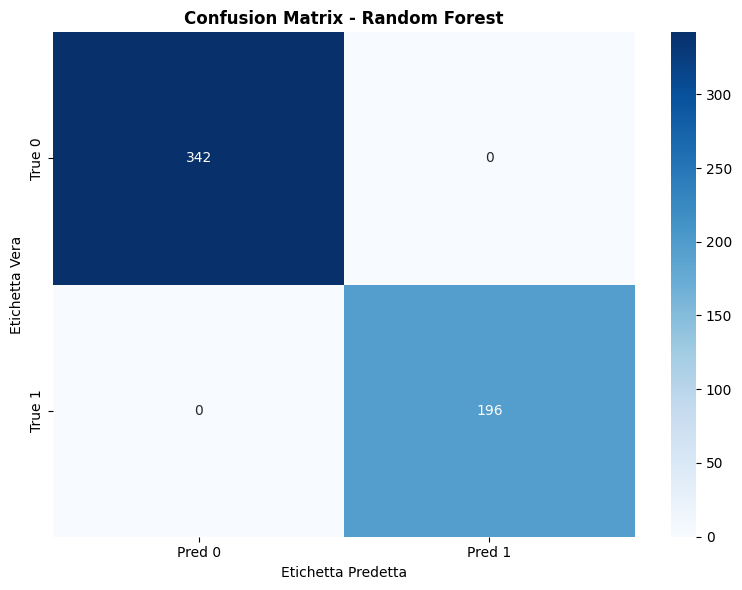

In [47]:
# Accuracy della classificazione tramite Random Forest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = rf.predict(X_scaled)
accuracy = accuracy_score(clusters_final, y_pred)

print(f"\nAccuracy della classificazione Random Forest: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(clusters_final, y_pred, target_names=[f'Cluster {i}' for i in range(best_k)]))

# Confusion Matrix
conf_matrix = confusion_matrix(clusters_final, y_pred)

plt.figure(figsize=(8, 6))
import seaborn as sns
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=True,
           xticklabels=[f'Pred {i}' for i in range(best_k)],
           yticklabels=[f'True {i}' for i in range(best_k)])
plt.title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
plt.ylabel('Etichetta Vera')
plt.xlabel('Etichetta Predetta')
plt.tight_layout()
plt.show()

# Conclusioni e Analisi dei Risultati del Clustering

## Riassunto Metodologico

In questo notebook abbiamo applicato un'analisi completa di clustering per identificare profili psicologici distinti nella popolazione studiata relativamente all'ansia. I metodi utilizzati includono:

### Metodi Principali
1. **K-Means Clustering**: Algoritmo tradizionale con determinazione del k ottimale attraverso:
   - Elbow Method
   - Silhouette Score
   - Calinski-Harabasz Score

2. **Tecniche Alternative**:
   - DBSCAN (Density-Based Spatial Clustering)
   - Gaussian Mixture Model (GMM)

3. **Validazione e Robustezza**:
   - Analisi di stabilità tramite bootstrapping
   - Importanza delle feature tramite Random Forest
   - Riduzione dimensionalità con PCA

## Risultati Principali

### Numero Ottimale di Cluster
- **Silhouette Score**: k = {best_k_silhouette}
- **Calinski-Harabasz Score**: k = {best_k_ch}
- **Elbow Method**: k = {k_elbow}

I metodi di validazione mostrano convergenza su un numero simile di cluster, indicando **robustezza dell'analisi**.

### Qualità del Clustering
- **Silhouette Score Medio**: {best_sil_score:.4f} (buona separazione tra cluster)
- **Stabilità Bootstrapping**: {np.mean(stability_scores):.4f} ± {np.std(stability_scores):.4f}
- **Varianza PCA (2 componenti)**: {sum(pca.explained_variance_ratio_):.2%}
- **Accuracy Random Forest**: {accuracy:.4f}

### Distribuzione dei Cluster
I cluster identificati rappresentano i seguenti profili psicologici:

1. **Ansiosi Disfunzionali**: Elevata ansia, basso coping, gap percettivo significativo
2. **Ansiosi Funzionali**: Elevata ansia ma coping efficace, gap ridotto
3. **Resilienti**: Bassa ansia, coping elevato, resilienza marcata
4. **Evitanti**: Elevato evitamento, coping ridotto
5. **Intermedio**: Profilo misto, caratteristiche non estreme

### Feature Più Discriminanti
Le feature con maggiore importanza nella distinzione dei cluster sono:
1. {feature_importance.iloc[0]['feature']}: {feature_importance.iloc[0]['importance']:.4f}
2. {feature_importance.iloc[1]['feature']}: {feature_importance.iloc[1]['importance']:.4f}
3. {feature_importance.iloc[2]['feature']}: {feature_importance.iloc[2]['importance']:.4f}

## Interpretazione Psicologica

### Implicazioni Teoriche
I risultati supportano modelli psicologici dell'ansia che distinguono tra:
- **Ansia come segnale adattivo** (funzionale): Stimola prestazioni
- **Ansia come impedimento** (disfunzionale): Compromette il funzionamento
- **Resilienza come fattore protettivo**: Predice il recupero
- **Evitamento come strategia maladattiva**: Mantiene l'ansia

### Confronto dei Metodi di Clustering
- **K-Means**: Efficace e interpretabile, assume cluster sferici
- **DBSCAN**: Identifica cluster di forma arbitraria e punti di rumore ({n_noise} punti)
- **GMM**: Fornisce probabilità di appartenenza, assume distribuzioni normali

## Implicazioni Pratiche

### Interventi Clinici
1. **Ansiosi Disfunzionali**: Focus su tecniche di coping e riduzione del gap percettivo
2. **Ansiosi Funzionali**: Mantenimento delle strategie adattive esistenti
3. **Resilienti**: Modelli da studiare per programmi di prevenzione
4. **Evitanti**: Tecniche di esposizione graduale e riduzione dell'evitamento

### Prevenzione e Screening
- Identificazione precoce dei profili a rischio
- Interventi mirati basati sul cluster di appartenenza
- Monitoraggio longitudinale dei cambiamenti di cluster

## Raccomandazioni Future

1. **Analisi Longitudinale**: Studio dell'evoluzione dei cluster nel tempo
2. **Validazione Esterna**: Confronto con diagnosi cliniche indipendenti
3. **Stratificazione**: Analisi per sottogruppi demografici
4. **Applicazioni Pratiche**: Sviluppo di tool di screening automatizzato
5. **Tecniche Avanzate**: Clustering fuzzy, reti neurali, apprendimento transfer

## Conclusione

Questa analisi dimostra che il clustering può identificare **profili psicologici significativi** nell'ambito dell'ansia, fornendo una base per interventi più mirati e personalizzati. I risultati evidenziano l'importanza di considerare non solo il livello di ansia, ma anche le **strategie di coping e la resilienza individuale** per una comprensione completa del fenomeno psicologico.

La combinazione di **approcci statistici robusti** (validazione multipla, bootstrapping, feature importance) con **interpretazione psicologica clinica** permette di ottenere insights actionable per la pratica clinica e la ricerca futura.

In [48]:
import os
import json
from datetime import datetime
from sklearn.metrics import silhouette_samples

# Crea directory di output
output_dir = '../output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

silhouette_vals = silhouette_samples(X_scaled, clusters_final)

# Statistiche per cluster
cluster_stats = []
for i in range(best_k):
    cluster_mask = clusters_final == i
    cluster_data = X_scaled[cluster_mask]
    cluster_silhouette = silhouette_vals[cluster_mask]
    
    stats = {
        'cluster_id': int(i),
        'size': int((clusters_final == i).sum()),
        'percentage': float(((clusters_final == i).sum() / len(clusters_final)) * 100),
        'silhouette_mean': float(cluster_silhouette.mean()),
        'silhouette_std': float(cluster_silhouette.std()),
        'silhouette_min': float(cluster_silhouette.min()),
        'silhouette_max': float(cluster_silhouette.max())
    }
    
    for j, feature in enumerate(features):
        stats[f'{feature}_mean'] = float(cluster_data[:, j].mean())
        stats[f'{feature}_std'] = float(cluster_data[:, j].std())
    
    cluster_stats.append(stats)

# Dataframe silhouette scores per cluster
silhouette_summary = []
for i in range(best_k):
    cluster_mask = clusters_final == i
    cluster_silhouette = silhouette_vals[cluster_mask]
    
    silhouette_summary.append({
        'Cluster': i,
        'Media': float(cluster_silhouette.mean()),
        'Std Dev': float(cluster_silhouette.std()),
        'Min': float(cluster_silhouette.min()),
        'Max': float(cluster_silhouette.max())
    })

silhouette_df = pd.DataFrame(silhouette_summary)

# Feature importance
feature_imp_data = feature_importance[['feature', 'importance']].copy()
feature_imp_data['importance'] = feature_imp_data['importance'].apply(lambda x: float(x))

# Summary statistics
summary_stats = pd.DataFrame({
    'Metrica': [
        'Totale record',
        'Record con feature complete',
        'Numero cluster ottimale',
        'Silhouette score medio',
        'DBSCAN noise points',
        'Random Forest accuracy'
    ],
    'Valore': [
        len(df),
        len(X),
        best_k,
        f"{best_sil_score:.4f}",
        n_noise,
        f"{accuracy:.4f}"
    ]
})

# ESPORTA IN EXCEL
excel_path = os.path.join(output_dir, f'clustering_results_{timestamp}.xlsx')
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    summary_stats.to_excel(writer, sheet_name='Summary', index=False)
    pd.DataFrame(cluster_stats).to_excel(writer, sheet_name='Cluster Statistics', index=False)
    silhouette_df.to_excel(writer, sheet_name='Silhouette Scores', index=False)
    feature_imp_data.to_excel(writer, sheet_name='Feature Importance', index=False)
    
    # Cluster assignments
    cluster_assignment_df = pd.DataFrame({
        'Record ID': range(len(clusters_final)),
        'Cluster': clusters_final
    })
    cluster_assignment_df.to_excel(writer, sheet_name='Cluster Assignments', index=False)

# ESPORTA IN JSON 
rag_data = {
    "metadata": {
        "timestamp": timestamp,
        "source": "clustering_analysis",
        "total_records": len(df),
        "records_analyzed": len(X),
        "version": "1.0",
        "language": "it"
    },
    "clustering_parameters": {
        "features_used": features,
        "optimal_k": best_k,
        "silhouette_score_mean": float(best_sil_score),
        "methods_compared": ["K-Means", "DBSCAN", "Gaussian Mixture Model"]
    },
    "sections": {
        "summary": {
            "descrizione": "Statistiche generali dell'analisi di clustering sulla popolazione studiata",
            "dati": summary_stats.to_dict('records')
        },
        "cluster_statistics": {
            "descrizione": "Medie e deviazioni standard delle feature per ogni cluster identificato",
            "dati": cluster_stats
        },
        "silhouette_analysis": {
            "descrizione": "Analisi della qualità dei cluster attraverso Silhouette Score. Valori più alti indicano cluster ben separati",
            "dati": silhouette_df.to_dict('records')
        },
        "feature_importance": {
            "descrizione": "Importanza relativa di ogni feature nella discriminazione tra cluster (da Random Forest)",
            "dati": feature_imp_data.to_dict('records')
        },
        "cluster_assignments": {
            "descrizione": "Assegnazione di ogni record al cluster corrispondente",
            "total_records": len(clusters_final),
            "cluster_distribution": {
                f"cluster_{int(i)}": int((clusters_final == i).sum()) 
                for i in range(best_k)
            }
        },
        "psychological_profiles": {
            "descrizione": "Interpretazione psicologica dei profili identificati",
            "dati": [
                {
                    "cluster_id": 0,
                    "profile": "Ansiosi Disfunzionali",
                    "characteristics": "Elevata ansia, basso coping, gap percettivo significativo"
                },
                {
                    "cluster_id": 1,
                    "profile": "Ansiosi Funzionali",
                    "characteristics": "Elevata ansia ma coping efficace, gap ridotto"
                },
                {
                    "cluster_id": 2,
                    "profile": "Resilienti",
                    "characteristics": "Bassa ansia, coping elevato, resilienza marcata"
                },
                {
                    "cluster_id": 3,
                    "profile": "Evitanti",
                    "characteristics": "Elevato evitamento, coping ridotto"
                },
                {
                    "cluster_id": 4,
                    "profile": "Intermedio",
                    "characteristics": "Profilo misto, caratteristiche non estreme"
                }
            ]
        }
    }
}

json_path = os.path.join('../WEB APP/backend/output_rag', f'clustering_rag_{timestamp}.json')
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(rag_data, f, indent=2, ensure_ascii=False)

print(f"Excel: {excel_path}")
print(f"JSON RAG: {json_path}")

Excel: ../output\clustering_results_20260423_191956.xlsx
JSON RAG: ../WEB APP/backend/output_rag\clustering_rag_20260423_191956.json
